In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# A simple Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attention = torch.cat([avg_out, max_out], dim=1)
        attention = torch.sigmoid(self.conv(attention))
        return x * attention

# The Main Static CNN Structure
class ProjectCNN(nn.Module):
    def __init__(self, use_attention=False, num_classes=10):
        super(ProjectCNN, self).__init__()
        self.use_attention = use_attention

        # Deep Network Blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Optional Attention Mechanism
        if self.use_attention:
            self.attention = SpatialAttention()

        # Dense Layers (Assuming input images are resized to 32x32)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        if self.use_attention:
            x = self.attention(x)

        x = x.view(-1, 64 * 8 * 8) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
# Initialize the three models
model_A = ProjectCNN(use_attention=False) # Baseline
model_B = ProjectCNN(use_attention=False) # Regularized
model_C = ProjectCNN(use_attention=True)  # Attention

# Configure the Optimizers and Loss Functions
experiments = {
    "Model_1_Baseline": {
        "model": model_A,
        "optimizer": torch.optim.Adam(model_A.parameters(), lr=0.001),
        "criterion": nn.CrossEntropyLoss()
    },
    "Model_2_Regularized": {
        "model": model_B,
        # L2 Penalty Term is implemented via 'weight_decay'
        "optimizer": torch.optim.RMSprop(model_B.parameters(), lr=0.001, weight_decay=1e-4),
        "criterion": nn.CrossEntropyLoss()
    },
    "Model_3_Attention_MSE": {
        "model": model_C,
        "optimizer": torch.optim.Adam(model_C.parameters(), lr=0.001),
        # MSE requires a specific target format compared to CrossEntropy
        "criterion": nn.MSELoss()
    }
}

In [5]:
def train_model(experiment_name, config, train_loader, epochs=10):
    model = config["model"]
    optimizer = config["optimizer"]
    criterion = config["criterion"]

    # Move to GPU if running on Colab
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loss_history = []

    print(f"--- Starting Training for {experiment_name} ---")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Note: MSE Loss requires one-hot encoded labels, CrossEntropy does not.
            if isinstance(criterion, nn.MSELoss):
                # Convert labels to one-hot for MSE
                labels_one_hot = F.one_hot(labels, num_classes=10).float()
                loss = criterion(outputs, labels_one_hot)
            else:
                loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

    return loss_history

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define the transformations
# Normalizing to the range [-1, 1] helps the optimizers converge faster
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load the Training Data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# Batch size of 64 is a standard starting point for optimization
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the Test Data
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# CIFAR-10 Classes
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [7]:
results = {}

# Run all three experiments
for exp_name, config in experiments.items():
    print(f"\nStarting {exp_name}...")
    # Train the model and save the loss history
    loss_history = train_model(exp_name, config, trainloader, epochs=10)
    results[exp_name] = loss_history


Starting Model_1_Baseline...
--- Starting Training for Model_1_Baseline ---
Epoch 1/10 - Loss: 1.2933
Epoch 2/10 - Loss: 0.9125
Epoch 3/10 - Loss: 0.7422
Epoch 4/10 - Loss: 0.6094
Epoch 5/10 - Loss: 0.4855
Epoch 6/10 - Loss: 0.3740
Epoch 7/10 - Loss: 0.2701
Epoch 8/10 - Loss: 0.1891
Epoch 9/10 - Loss: 0.1328
Epoch 10/10 - Loss: 0.1095

Starting Model_2_Regularized...
--- Starting Training for Model_2_Regularized ---
Epoch 1/10 - Loss: 1.3733
Epoch 2/10 - Loss: 0.9835
Epoch 3/10 - Loss: 0.8273
Epoch 4/10 - Loss: 0.7078
Epoch 5/10 - Loss: 0.6002
Epoch 6/10 - Loss: 0.5026
Epoch 7/10 - Loss: 0.4147
Epoch 8/10 - Loss: 0.3331
Epoch 9/10 - Loss: 0.2670
Epoch 10/10 - Loss: 0.2118

Starting Model_3_Attention_MSE...
--- Starting Training for Model_3_Attention_MSE ---
Epoch 1/10 - Loss: 0.0620
Epoch 2/10 - Loss: 0.0470
Epoch 3/10 - Loss: 0.0411
Epoch 4/10 - Loss: 0.0369
Epoch 5/10 - Loss: 0.0332
Epoch 6/10 - Loss: 0.0297
Epoch 7/10 - Loss: 0.0267
Epoch 8/10 - Loss: 0.0237
Epoch 9/10 - Loss: 0.02

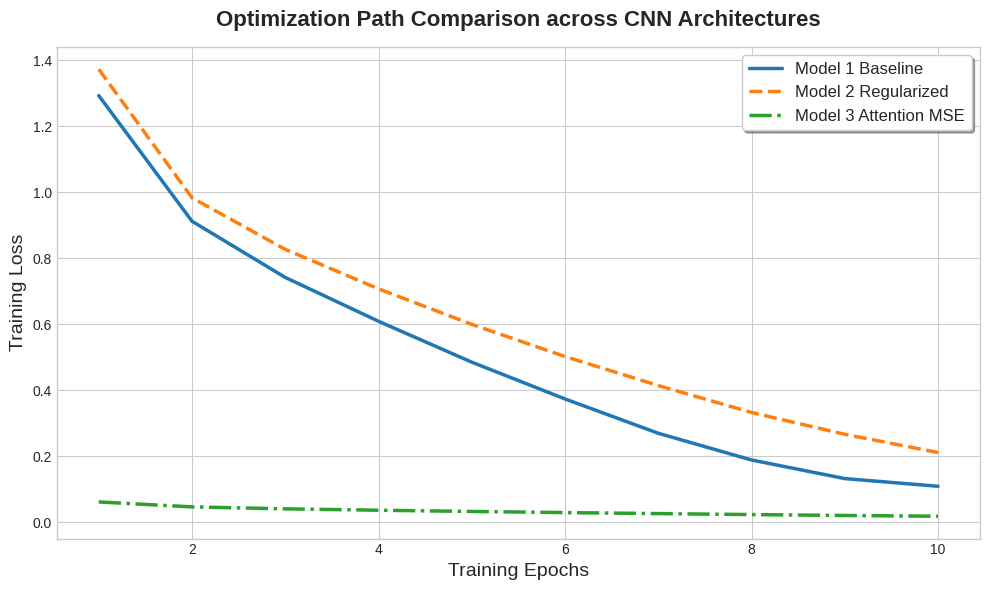

In [8]:
import matplotlib.pyplot as plt

# Set the style for a professional, academic-looking plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Define distinct colors and line styles for clarity
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
styles = ['-', '--', '-.']

# Loop through the results dictionary and plot each model's loss history
for idx, (exp_name, loss_history) in enumerate(results.items()):
    # Create the x-axis (Epochs 1 to N)
    epochs = range(1, len(loss_history) + 1)

    # Plot the curve
    plt.plot(epochs, loss_history,
             color=colors[idx],
             linestyle=styles[idx],
             linewidth=2.5,
             label=exp_name.replace('_', ' '))

# Add report-ready labels and title
plt.title('Optimization Path Comparison across CNN Architectures', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Epochs', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)

# Add a legend to differentiate the models
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

# Tight layout ensures everything fits perfectly
plt.tight_layout()

# Save the figure so you can download it and paste it into your report!
plt.savefig('optimization_comparison_plot.png', dpi=300)

# Display the plot
plt.show()

In [9]:
def calculate_accuracy(model, loader):
    # Switch to evaluation mode (turns off Dropout and Batch Norm behavior)
    model.eval()
    correct = 0
    total = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Disable gradient calculations for faster performance and less memory usage
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Get predictions
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Run evaluation for all experiments
test_results = {}
print("--- Final Model Evaluation ---")
for exp_name, config in experiments.items():
    acc = calculate_accuracy(config["model"], testloader)
    test_results[exp_name] = acc
    print(f"{exp_name:25} | Test Accuracy: {acc:.2f}%")

--- Final Model Evaluation ---
Model_1_Baseline          | Test Accuracy: 72.44%
Model_2_Regularized       | Test Accuracy: 68.04%
Model_3_Attention_MSE     | Test Accuracy: 73.32%


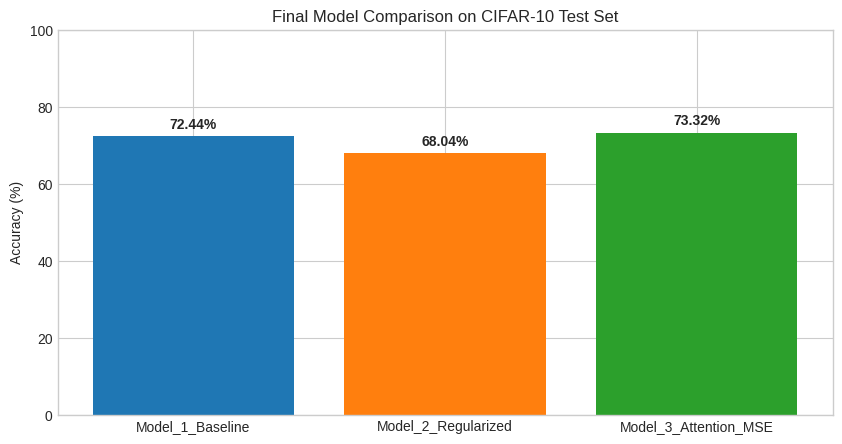

In [10]:
import matplotlib.pyplot as plt

names = list(test_results.keys())
values = list(test_results.values())

plt.figure(figsize=(10, 5))
plt.bar(names, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Accuracy (%)')
plt.title('Final Model Comparison on CIFAR-10 Test Set')
plt.ylim(0, 100) # Keep the scale consistent

# Add labels on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

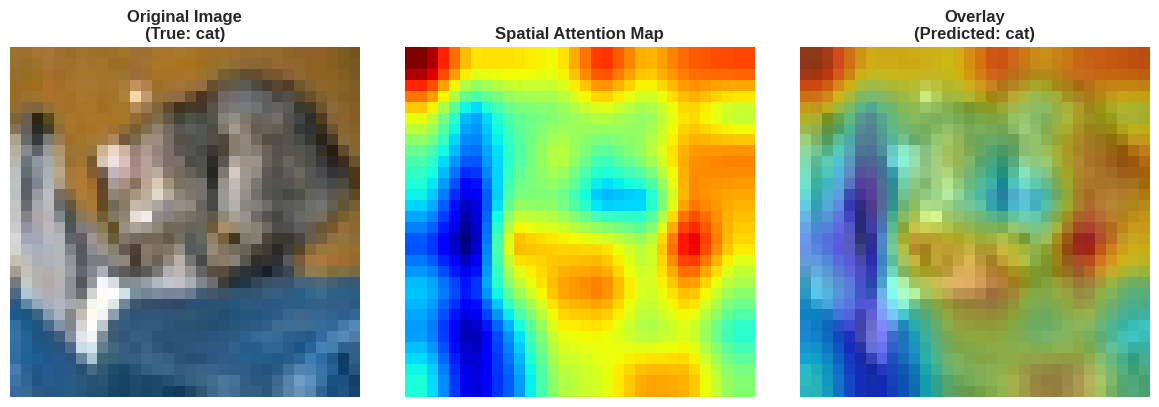

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# 1. Get a single image from the test set
dataiter = iter(testloader)
images, labels = next(dataiter)

# Select the first image in the batch
single_image = images[0].unsqueeze(0)
true_label = classes[labels[0]]

# Move to device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
single_image = single_image.to(device)

# 2. Extract the Attention Map from Model 3
model_C = experiments["Model_3_Attention_MSE"]["model"]
model_C.eval()

with torch.no_grad():
    # Pass the image through the first few layers manually to reach the attention module
    x = model_C.pool(F.relu(model_C.conv1(single_image)))
    features = model_C.pool(F.relu(model_C.conv2(x)))

    # Recreate the Spatial Attention logic to isolate the heat map
    avg_out = torch.mean(features, dim=1, keepdim=True)
    max_out, _ = torch.max(features, dim=1, keepdim=True)
    attn_input = torch.cat([avg_out, max_out], dim=1)

    # This is the actual attention mask (values between 0 and 1)
    attention_map = torch.sigmoid(model_C.attention.conv(attn_input))

    # Get the final prediction
    output = model_C(single_image)
    _, predicted = torch.max(output, 1)
    predicted_label = classes[predicted.item()]

# 3. Process the tensors for matplotlib
# Un-normalize the original image so it looks normal
img_display = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
img_display = img_display * 0.5 + 0.5

# Resize the attention map (which is 8x8) back to the image size (32x32)
attn_display = F.interpolate(attention_map, size=(32, 32), mode='bilinear', align_corners=False)
attn_display = attn_display.squeeze().cpu().numpy()

# 4. Plot the Original Image vs. The Attention Map
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original Image
axes[0].imshow(img_display)
axes[0].set_title(f"Original Image\n(True: {true_label})", fontweight='bold')
axes[0].axis('off')

# Attention Heatmap
im = axes[1].imshow(attn_display, cmap='jet')
axes[1].set_title("Spatial Attention Map", fontweight='bold')
axes[1].axis('off')

# Overlay
axes[2].imshow(img_display)
axes[2].imshow(attn_display, cmap='jet', alpha=0.5) # alpha makes it semi-transparent
axes[2].set_title(f"Overlay\n(Predicted: {predicted_label})", fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('explainable_ai_attention.png', dpi=300)
plt.show()